# 08 - Platform comparison and external validation

**Purpose.** This notebook is the clean synthesis layer for Assignment 2. It compares Reddit and YouTube using the upstream outputs from preprocessing, sentiment/topic modelling, network analysis, diffusion analysis, and community analysis. It then checks whether platform discussion patterns move with external oil/jet-fuel price series.

This notebook does **not** recompute upstream models. It reads persisted CSV/JSON artifacts and writes comparison/validation outputs under `data/processed/06_comparison/`.

## 1 - Setup

The notebook uses only standard analysis libraries plus `scipy` for tests. All outputs are written to `data/processed/06_comparison/` and `plots/`.

In [1]:
from __future__ import annotations

import json
import math
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJECT_ROOT / "data"
PROCESSED = DATA / "processed"
PREPROCESSED = PROCESSED / "01_preprocessed"
SENTIMENT_TOPICS = PROCESSED / "03_sentiment_topics"
NETWORKS = PROCESSED / "04_networks"
DIFFUSION = PROCESSED / "05_diffusion"
COMPARISON = PROCESSED / "06_comparison"
COMMUNITY = PROCESSED / "07_community_sentiment_topics"
EXTERNAL = PROCESSED / "00_external"
PLOTS = PROJECT_ROOT / "plots"

COMPARISON.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

REDDIT_COLOR = "#3b6fa1"
YOUTUBE_COLOR = "#c45a3d"
NEUTRAL_COLOR = "#777777"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs    : {COMPARISON}")

Project root: /Users/matteoomizzolo/Desktop/Courses 2026-2027/NLP/Assignment-02
Outputs    : /Users/matteoomizzolo/Desktop/Courses 2026-2027/NLP/Assignment-02/data/processed/06_comparison


## 2 - Input contract

This notebook expects these upstream artifacts:

| Stage | File(s) | Purpose |
|---|---|---|
| Preprocessing | `01_preprocessed/reddit_comments.csv`, `youtube_comments.csv`, `youtube_videos.csv` | base comment metadata and platform volumes |
| Sentiment | `03_sentiment_topics/sentiment_comment_level.csv`, `sentiment_summary_by_platform.csv`, `sentiment_daily_by_platform.csv` | transformer headline sentiment plus VADER baseline |
| Topics | `topics_lda_platform_dominant_per_comment_labelled.csv`, `topic_prevalence_platform_specific.csv`, `topics_combined_doc_topic.csv`, `topics_combined_labelled.csv` | platform-specific topics and common-topic comparison |
| Network | `04_networks/network_shape_comparison.csv`, `robustness_checks.csv` | platform network shape and robustness |
| Community | `07_community_sentiment_topics/community_coverage_summary.csv`, `community_threshold_summary.csv`, `community_threshold_justification.csv`, `community_report_grade_subset.csv`, `community_atlas.csv` | community join coverage, threshold justification, and interpretability |
| Diffusion | `05_diffusion/reddit_cascade_metrics.csv`, `youtube_engagement_metrics.csv` | within-platform spread/engagement |
| External | `00_external/energy_price_timeline.csv` | jet fuel, Brent, WTI price series |


In [2]:
def read_required(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required input: {path}")
    return pd.read_csv(path, **kwargs)


def read_optional(path: Path, **kwargs) -> pd.DataFrame:
    return pd.read_csv(path, **kwargs) if path.exists() else pd.DataFrame()


def pct(part: float, whole: float) -> float:
    return float(part / whole * 100) if whole else float("nan")


def cramers_v(table: np.ndarray) -> float:
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.sum()
    k = min(table.shape) - 1
    return math.sqrt(chi2 / (n * k)) if n and k else float("nan")


def rank_biserial(a: pd.Series, b: pd.Series) -> float:
    a = pd.Series(a).dropna().to_numpy(dtype=float)
    b = pd.Series(b).dropna().to_numpy(dtype=float)
    if len(a) == 0 or len(b) == 0:
        return float("nan")
    u = stats.mannwhitneyu(a, b, alternative="two-sided").statistic
    return float(2 * u / (len(a) * len(b)) - 1)


def bootstrap_two_sample(func, a, b, n_resamples: int = 1000, seed: int = 0) -> tuple[float, float]:
    a = pd.Series(a).dropna().to_numpy(dtype=float)
    b = pd.Series(b).dropna().to_numpy(dtype=float)
    if len(a) == 0 or len(b) == 0:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_resamples):
        aa = rng.choice(a, size=len(a), replace=True)
        bb = rng.choice(b, size=len(b), replace=True)
        values.append(float(func(aa, bb)))
    return float(np.percentile(values, 2.5)), float(np.percentile(values, 97.5))


def short_label(value: object, width: int = 38) -> str:
    return "\n".join(textwrap.wrap(str(value), width=width, break_long_words=False))


def safe_divide(a: float, b: float) -> float:
    return float(a / b) if b else float("nan")

## 3 - Load and harmonize data

In [3]:
reddit_comments = read_required(PREPROCESSED / "reddit_comments.csv", low_memory=False)
youtube_comments = read_required(PREPROCESSED / "youtube_comments.csv", low_memory=False)
youtube_videos = read_optional(PREPROCESSED / "youtube_videos.csv", low_memory=False)

reddit_base = reddit_comments.copy()
reddit_base["scope"] = reddit_base["subreddit"]

youtube_base = youtube_comments.copy()
if not youtube_videos.empty and {"video_id", "channel_title"}.issubset(youtube_videos.columns):
    youtube_base = youtube_base.merge(
        youtube_videos[["video_id", "channel_title"]].drop_duplicates("video_id"),
        on="video_id",
        how="left",
    )
youtube_base["scope"] = youtube_base.get("channel_title", youtube_base.get("channel_id"))

base_cols = [
    "platform", "comment_id", "author_hash", "date", "clean_text", "token_count",
    "char_count", "scope", "subreddit", "video_id", "channel_id", "is_reply",
    "depth", "score", "like_count", "reply_count",
]
for df in (reddit_base, youtube_base):
    for col in base_cols:
        if col not in df.columns:
            df[col] = pd.NA

comments = pd.concat([reddit_base[base_cols], youtube_base[base_cols]], ignore_index=True)
comments["date"] = pd.to_datetime(comments["date"], errors="coerce")

sentiment = read_required(SENTIMENT_TOPICS / "sentiment_comment_level.csv", low_memory=False)
sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce")
sentiment["sentiment_label"] = sentiment.get("headline_sentiment_label", sentiment.get("tx_label"))
sentiment["sentiment_score"] = sentiment.get("headline_sentiment_score", sentiment.get("tx_compound"))

topic_dom = read_required(SENTIMENT_TOPICS / "topics_lda_platform_dominant_per_comment_labelled.csv", low_memory=False)
topic_prev = read_required(SENTIMENT_TOPICS / "topic_prevalence_platform_specific.csv")
topic_confidence = read_required(SENTIMENT_TOPICS / "topic_confidence_summary_by_platform.csv")
combined_doc_topic = read_required(SENTIMENT_TOPICS / "topics_combined_doc_topic.csv")
combined_topic_labels = read_optional(SENTIMENT_TOPICS / "topics_combined_labelled.csv")
topic_alignment = read_optional(SENTIMENT_TOPICS / "topics_lda_reddit_youtube_alignment.csv")

network_shape = read_required(NETWORKS / "network_shape_comparison.csv")
network_robustness = read_required(NETWORKS / "robustness_checks.csv")

community_coverage = read_required(COMMUNITY / "community_coverage_summary.csv")
community_thresholds = read_required(COMMUNITY / "community_threshold_summary.csv")
community_threshold_justification = read_optional(COMMUNITY / "community_threshold_justification.csv")
community_report_grade_subset = read_optional(COMMUNITY / "community_report_grade_subset.csv")
community_atlas = read_required(COMMUNITY / "community_atlas.csv")

reddit_cascades = read_optional(DIFFUSION / "reddit_cascade_metrics.csv")
youtube_engagement = read_optional(DIFFUSION / "youtube_engagement_metrics.csv")

prices_long = read_required(EXTERNAL / "energy_price_timeline.csv")
prices_long["date"] = pd.to_datetime(prices_long["date"], errors="coerce")

print(f"Comments : {len(comments):,} ({comments['platform'].value_counts().to_dict()})")
print(f"Sentiment: {len(sentiment):,}")
print(f"Prices   : {prices_long['series_id'].nunique()} series, {len(prices_long):,} rows")


Comments : 43,298 ({'youtube': 26136, 'reddit': 17162})
Sentiment: 43,298
Prices   : 3 series, 160 rows


# Platform comparison

The first half of the notebook compares platforms on aligned dimensions: volume, sentiment, topics, network shape, community coverage, and diffusion/engagement. This is the main evidence for platform-level claims.

## 4 - Platform audit and synthesis table

In [4]:
volume_rows = []
for platform, g in comments.groupby("platform"):
    volume_rows.append({
        "platform": platform,
        "comments": int(len(g)),
        "authors": int(g["author_hash"].nunique()),
        "scopes": int(g["scope"].nunique(dropna=True)),
        "first_date": g["date"].min().date() if g["date"].notna().any() else pd.NaT,
        "last_date": g["date"].max().date() if g["date"].notna().any() else pd.NaT,
        "active_dates": int(g["date"].dt.date.nunique()),
        "median_token_count": float(g["token_count"].median()),
    })
volume_summary = pd.DataFrame(volume_rows)

sentiment_summary = (
    sentiment.groupby("platform")
    .agg(
        sentiment_rows=("comment_id", "count"),
        headline_score_mean=("sentiment_score", "mean"),
        headline_score_median=("sentiment_score", "median"),
        pct_negative=("sentiment_label", lambda s: float((s == "negative").mean() * 100)),
        pct_neutral=("sentiment_label", lambda s: float((s == "neutral").mean() * 100)),
        pct_positive=("sentiment_label", lambda s: float((s == "positive").mean() * 100)),
        vader_compound_mean=("vader_compound", "mean"),
    )
    .reset_index()
)

topic_summary = (
    topic_dom.groupby("platform")
    .agg(
        topic_rows=("comment_id", "count"),
        dominant_topic_concentration=("topic_label", lambda s: float(s.value_counts(normalize=True).iloc[0] * 100)),
        mean_topic_probability=("topic_probability", "mean"),
    )
    .reset_index()
)

if not community_threshold_justification.empty and "chosen_for_report" in community_threshold_justification.columns:
    chosen_thresholds = community_threshold_justification[community_threshold_justification["chosen_for_report"]].copy()
else:
    chosen_thresholds = community_thresholds[community_thresholds["min_comments"] == 100].copy()

community_summary = community_coverage.merge(
    chosen_thresholds[[
        "platform", "min_comments", "communities", "pct_assigned_comments",
        "max_95pct_binomial_half_width_pct",
    ]].rename(columns={
        "min_comments": "report_grade_min_comments",
        "communities": "report_grade_communities",
        "pct_assigned_comments": "pct_assigned_comments_report_grade",
    }),
    on="platform",
    how="left",
)
# Backward-compatible names for existing plots/tables.
community_summary["communities_ge_100_comments"] = community_summary["report_grade_communities"]
community_summary["pct_assigned_comments_in_ge_100"] = community_summary["pct_assigned_comments_report_grade"]

diffusion_rows = []
if not reddit_cascades.empty:
    diffusion_rows.append({
        "platform": "reddit",
        "diffusion_units": int(len(reddit_cascades)),
        "median_spread_size": float(reddit_cascades["size"].median()),
        "mean_spread_size": float(reddit_cascades["size"].mean()),
        "median_max_depth": float(reddit_cascades["max_depth"].median()),
        "median_time_to_first_reply_sec": float(reddit_cascades["time_to_first_reply_sec"].median()),
    })
if not youtube_engagement.empty:
    diffusion_rows.append({
        "platform": "youtube",
        "diffusion_units": int(len(youtube_engagement)),
        "median_spread_size": float((youtube_engagement["n_replies"] + 1).median()),
        "mean_spread_size": float((youtube_engagement["n_replies"] + 1).mean()),
        "median_max_depth": float(youtube_engagement["had_any_reply"].astype(int).median()),
        "median_time_to_first_reply_sec": float(youtube_engagement["time_to_first_reply_sec"].median()),
    })
diffusion_summary = pd.DataFrame(diffusion_rows)

platform_synthesis = (
    volume_summary
    .merge(sentiment_summary, on="platform", how="left")
    .merge(topic_summary, on="platform", how="left")
    .merge(network_shape, on="platform", how="left")
    .merge(network_robustness, on="platform", how="left")
    .merge(community_summary, on="platform", how="left")
    .merge(diffusion_summary, on="platform", how="left")
)
platform_synthesis.to_csv(COMPARISON / "platform_comparison.csv", index=False)
platform_synthesis


,platform,comments,authors,scopes,first_date,last_date,active_dates,median_token_count,sentiment_rows,headline_score_mean,headline_score_median,pct_negative,pct_neutral,pct_positive,vader_compound_mean,topic_rows,dominant_topic_concentration,mean_topic_probability,nodes,edges,largest_wcc_pct,reciprocity_pct,avg_clustering,modularity,gini_pagerank,top_1pct_share,tau_mean,tau_lo,tau_hi,tau_p_gt_zero,topk_overlap_mean,topk_overlap_lo,topk_overlap_hi,tau_resamples,edge_keep_fraction,top_k,ari_mean,ari_lo,ari_hi,ari_p_gt_zero,ari_pairs,louvain_seeds,communities_mean,communities_min,communities_max,modularity_mean,modularity_lo,modularity_hi,robustness_note,total_comments,comments_with_community,pct_comments_with_community,total_authors,authors_with_community,pct_authors_with_community,comments_with_sentiment,comments_with_topic,analytic_comments,pct_analytic_comments,report_grade_min_comments,report_grade_communities,pct_assigned_comments_report_grade,max_95pct_binomial_half_width_pct,communities_ge_100_comments,pct_assigned_comments_in_ge_100,diffusion_units,median_spread_size,mean_spread_size,median_max_depth,median_time_to_first_reply_sec
0,reddit,17162,10795,8,2026-03-01,2026-05-15,75,8.0,17162,-0.405636,-0.538810,57.137863,35.765062,7.097075,-0.055666,17162,34.826943,0.668943,7938,10668,88.851096,28.196475,0.023914,0.901620,0.618572,0.179437,0.356371,0.186966,0.454091,0.009901,0.455,0.35,0.55000,100,0.9,20,0.742740,0.685191,0.803706,0.021739,45,10,357.2,354,359,0.901163,0.900714,0.901798,Computed: 100 PageRank edge-drop perturbations at 90% edge retention; 10 Louvain seeds (45 ARI pairs). Empirical p-values are one-sided for statistic > 0 wi...,17162,13913,81.068640,10795,7885,73.043075,17162,17162,13913,81.068640,100,40,88.370589,9.8,40,88.370589,55,305.0,312.036364,9.0,176.0
1,youtube,26136,19676,114,2026-03-01,2026-05-15,76,7.0,26136,-0.344463,-0.497248,54.289103,33.811601,11.899296,-0.057510,26136,38.410621,0.671770,5789,5229,44.964588,0.076496,0.004633,0.970542,0.347996,0.129286,0.684671,0.595513,0.775543,0.009901,0.763,0.70,0.82625,100,0.9,20,0.938408,0.899346,0.985900,0.021739,45,10,833.5,833,834,0.970680,0.970165,0.971124,Computed: 100 PageRank edge-drop perturbations at 90% edge retention; 10 Louvain seeds (45 ARI pairs). Empirical p-values are one-sided for statistic > 0 wi...,26136,10725,41.035354,19676,5789,29.421630,26136,26136,10725,41.035354,100,28,52.764569,9.8,28,52.764569,18012,1.0,1.402454,0.0,7641.0


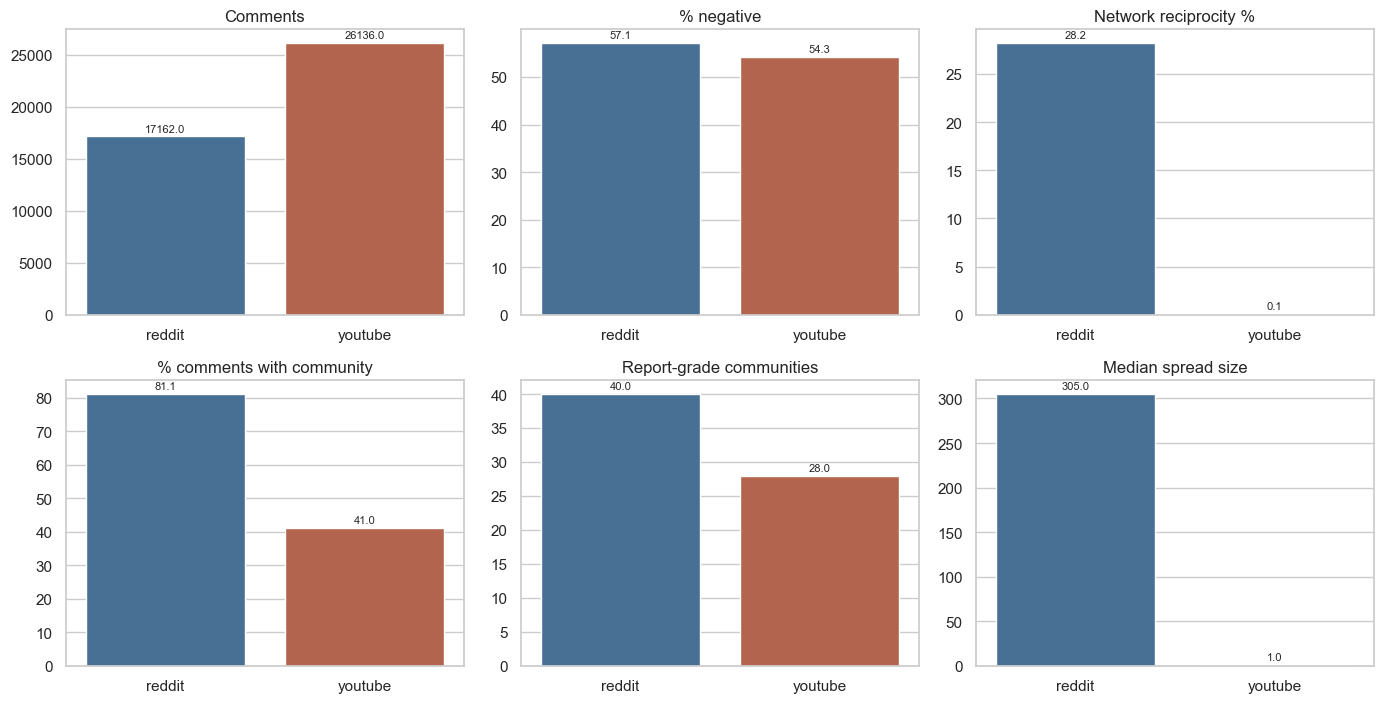

In [5]:
dashboard_metrics = [
    ("comments", "Comments"),
    ("pct_negative", "% negative"),
    ("reciprocity_pct", "Network reciprocity %"),
    ("pct_comments_with_community", "% comments with community"),
    ("report_grade_communities", "Report-grade communities"),
    ("median_spread_size", "Median spread size"),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7.2))
for ax, (metric, title) in zip(axes.ravel(), dashboard_metrics):
    data = platform_synthesis[["platform", metric]].copy()
    sns.barplot(
        data=data,
        x="platform",
        y=metric,
        hue="platform",
        palette={"reddit": REDDIT_COLOR, "youtube": YOUTUBE_COLOR},
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)
plt.tight_layout()
out = PLOTS / "platform_comparison_dashboard.png"
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()


## 5 - Sentiment comparison

In [6]:
reddit_scores = sentiment.loc[sentiment["platform"] == "reddit", "sentiment_score"].dropna()
youtube_scores = sentiment.loc[sentiment["platform"] == "youtube", "sentiment_score"].dropna()

mw = stats.mannwhitneyu(reddit_scores, youtube_scores, alternative="two-sided")
welch = stats.ttest_ind(reddit_scores, youtube_scores, equal_var=False, nan_policy="omit")
rb = rank_biserial(reddit_scores, youtube_scores)
rb_lo, rb_hi = bootstrap_two_sample(rank_biserial, reddit_scores, youtube_scores, n_resamples=1000, seed=7)
mean_diff = float(reddit_scores.mean() - youtube_scores.mean())
mean_diff_lo, mean_diff_hi = bootstrap_two_sample(lambda a, b: np.mean(a) - np.mean(b), reddit_scores, youtube_scores, n_resamples=1000, seed=8)

label_table = pd.crosstab(sentiment["sentiment_label"], sentiment["platform"])
chi2, chi_p, _, _ = stats.chi2_contingency(label_table)

sentiment_tests = pd.DataFrame([
    {
        "comparison": "reddit_minus_youtube",
        "test": "mean_difference_transformer_score",
        "statistic": mean_diff,
        "p_value": np.nan,
        "effect_size": mean_diff,
        "effect_size_ci_lo": mean_diff_lo,
        "effect_size_ci_hi": mean_diff_hi,
        "n_reddit": int(len(reddit_scores)),
        "n_youtube": int(len(youtube_scores)),
        "interpretation": "Negative values mean Reddit is more negative on average.",
    },
    {
        "comparison": "reddit_vs_youtube",
        "test": "mannwhitney_rank_biserial",
        "statistic": float(mw.statistic),
        "p_value": float(mw.pvalue),
        "effect_size": rb,
        "effect_size_ci_lo": rb_lo,
        "effect_size_ci_hi": rb_hi,
        "n_reddit": int(len(reddit_scores)),
        "n_youtube": int(len(youtube_scores)),
        "interpretation": "Rank-biserial near zero means little platform separation in score distribution.",
    },
    {
        "comparison": "reddit_vs_youtube",
        "test": "welch_t_transformer_score",
        "statistic": float(welch.statistic),
        "p_value": float(welch.pvalue),
        "effect_size": np.nan,
        "effect_size_ci_lo": np.nan,
        "effect_size_ci_hi": np.nan,
        "n_reddit": int(len(reddit_scores)),
        "n_youtube": int(len(youtube_scores)),
        "interpretation": "Large samples can make small differences statistically detectable.",
    },
    {
        "comparison": "sentiment_label_by_platform",
        "test": "chi_square_cramers_v",
        "statistic": float(chi2),
        "p_value": float(chi_p),
        "effect_size": cramers_v(label_table.to_numpy()),
        "effect_size_ci_lo": np.nan,
        "effect_size_ci_hi": np.nan,
        "n_reddit": int((sentiment["platform"] == "reddit").sum()),
        "n_youtube": int((sentiment["platform"] == "youtube").sum()),
        "interpretation": "Cramer's V should be used for substantive size, not p-value alone.",
    },
])
sentiment_tests.to_csv(COMPARISON / "sentiment_test_results.csv", index=False)
sentiment_tests

,comparison,test,statistic,p_value,effect_size,effect_size_ci_lo,effect_size_ci_hi,n_reddit,n_youtube,interpretation
0,reddit_minus_youtube,mean_difference_transformer_score,-6.117238e-02,NaN,-0.061172,-0.070941,-0.051746,17162,26136,Negative values mean Reddit is more negative on average.
1,reddit_vs_youtube,mannwhitney_rank_biserial,2.163192e+08,4.051325e-10,-0.035465,-0.046149,-0.024050,17162,26136,Rank-biserial near zero means little platform separation in score distribution.
2,reddit_vs_youtube,welch_t_transformer_score,-1.260018e+01,2.467858e-36,NaN,NaN,NaN,17162,26136,Large samples can make small differences statistically detectable.
3,sentiment_label_by_platform,chi_square_cramers_v,2.656039e+02,2.112722e-58,0.078322,NaN,NaN,17162,26136,"Cramer's V should be used for substantive size, not p-value alone."


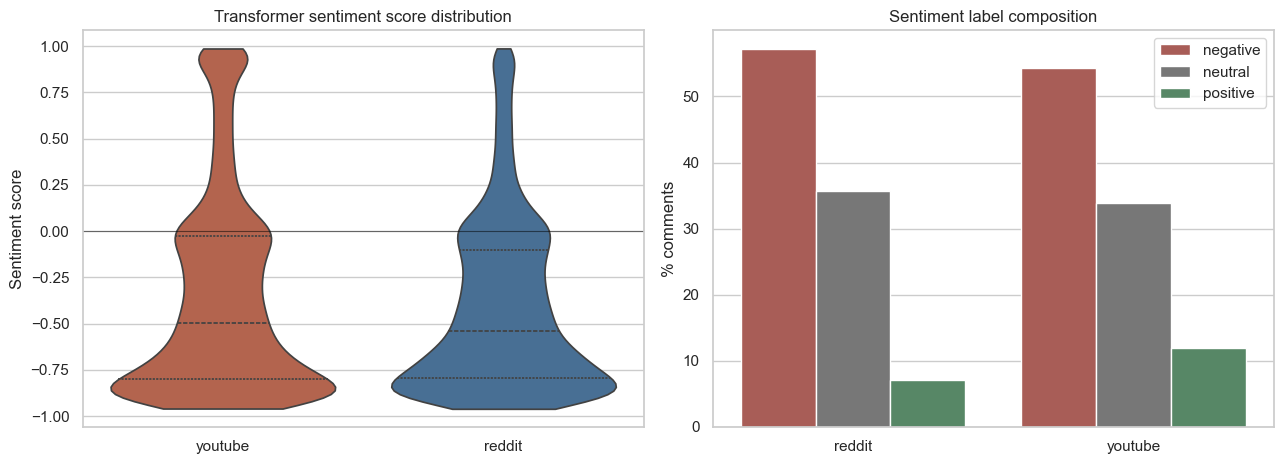

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.violinplot(
    data=sentiment,
    x="platform",
    y="sentiment_score",
    hue="platform",
    palette={"reddit": REDDIT_COLOR, "youtube": YOUTUBE_COLOR},
    legend=False,
    cut=0,
    inner="quartile",
    ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_title("Transformer sentiment score distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sentiment score")

sent_comp = (
    sentiment.groupby(["platform", "sentiment_label"])
    .size()
    .rename("comments")
    .reset_index()
)
sent_comp["pct"] = sent_comp["comments"] / sent_comp.groupby("platform")["comments"].transform("sum") * 100
sns.barplot(
    data=sent_comp,
    x="platform",
    y="pct",
    hue="sentiment_label",
    hue_order=["negative", "neutral", "positive"],
    palette={"negative": "#b5524a", "neutral": NEUTRAL_COLOR, "positive": "#4f8f63"},
    ax=axes[1],
)
axes[1].set_title("Sentiment label composition")
axes[1].set_xlabel("")
axes[1].set_ylabel("% comments")
axes[1].legend(title="")

plt.tight_layout()
out = PLOTS / "sentiment_platform_comparison_clean.png"
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()

## 6 - Topic comparison

There are two valid topic comparisons:

1. **Platform-specific topics** are best for interpretation inside each platform.
2. **Combined topics** provide a common topic space for a formal platform association test.

The notebook reports both so that the comparison is readable and statistically grounded.

In [8]:
platform_topic_table = topic_prev.copy()
platform_topic_table.to_csv(COMPARISON / "platform_specific_topic_prevalence.csv", index=False)

combined_dom_idx = combined_doc_topic.groupby("comment_id")["topic_weight"].idxmax()
combined_dom = combined_doc_topic.loc[combined_dom_idx, ["comment_id", "platform", "topic_id", "topic_weight"]].copy()
if not combined_topic_labels.empty:
    label_cols = [c for c in ["topic_id", "manual_label", "suggested_label"] if c in combined_topic_labels.columns]
    combined_dom = combined_dom.merge(combined_topic_labels[label_cols], on="topic_id", how="left")
    combined_dom["topic_label"] = combined_dom.get("manual_label").fillna(combined_dom.get("suggested_label"))
else:
    combined_dom["topic_label"] = "topic_" + combined_dom["topic_id"].astype(str)

combined_ct = pd.crosstab(combined_dom["topic_label"], combined_dom["platform"])
combined_chi2, combined_p, _, _ = stats.chi2_contingency(combined_ct)
topic_platform_test = pd.DataFrame([{
    "test": "combined_topic_by_platform_chi_square",
    "chi2": float(combined_chi2),
    "p_value": float(combined_p),
    "cramers_v": cramers_v(combined_ct.to_numpy()),
    "topics": int(combined_ct.shape[0]),
    "platforms": int(combined_ct.shape[1]),
    "interpretation": "Uses common combined-topic space; Cramer's V is the substantive effect size.",
}])
topic_platform_test.to_csv(COMPARISON / "topic_platform_chi2.csv", index=False)

combined_topic_share = combined_ct.div(combined_ct.sum(axis=0), axis=1).mul(100).reset_index()
combined_topic_share.to_csv(COMPARISON / "combined_topic_prevalence_by_platform.csv", index=False)

if not topic_alignment.empty:
    topic_alignment.to_csv(COMPARISON / "platform_topic_alignment_for_interpretation.csv", index=False)

print(topic_platform_test.to_string(index=False))
platform_topic_table

                                 test       chi2      p_value  cramers_v  topics  platforms                                                               interpretation
combined_topic_by_platform_chi_square 320.076883 4.488547e-69   0.087582       4          2 Uses common combined-topic space; Cramer's V is the substantive effect size.


,platform,topic_label,comments,pct_within_platform
0,reddit,Strait of Hormuz and oil-market disruption,5977,34.826943
1,reddit,"Trump, markets, and US economic reaction",5794,33.760634
2,reddit,Iran-US geopolitical conflict and war risk,5391,31.412423
3,youtube,"Iran-US conflict, Israel, and military escalation",10039,38.410621
4,youtube,Global power politics and US-China rivalry,8510,32.560453
5,youtube,"Oil, gas prices, and global energy supply",7587,29.028926


# External validation

External validation asks whether platform discussion volume or negativity moves with market price series. The notebook compares:

- US Gulf Coast jet fuel spot price (`DJFUELUSGULF`)
- Brent crude spot price (`DCOILBRENTEU`)
- WTI crude spot price (`DCOILWTICO`)

For each series, the notebook computes raw and first-differenced lag correlations. Raw correlations show level co-movement; differenced correlations are the safer check because they reduce shared-trend artifacts.

## 7 - Daily discussion outcomes

In [11]:
daily_platform = (
    sentiment.dropna(subset=["date"])
    .groupby([pd.Grouper(key="date", freq="D"), "platform"])
    .agg(
        comments=("comment_id", "count"),
        mean_sentiment=("sentiment_score", "mean"),
        pct_negative=("sentiment_label", lambda s: float((s == "negative").mean() * 100)),
    )
    .reset_index()
)
daily_all = (
    sentiment.dropna(subset=["date"])
    .groupby(pd.Grouper(key="date", freq="D"))
    .agg(
        comments=("comment_id", "count"),
        mean_sentiment=("sentiment_score", "mean"),
        pct_negative=("sentiment_label", lambda s: float((s == "negative").mean() * 100)),
    )
    .reset_index()
)
daily_all["platform"] = "all"
daily_outcomes = pd.concat([daily_platform, daily_all], ignore_index=True)
daily_outcomes.to_csv(COMPARISON / "daily_discussion_outcomes.csv", index=False)
daily_outcomes.head()

,date,platform,comments,mean_sentiment,pct_negative
0,2026-03-01,reddit,159,-0.182631,35.220126
1,2026-03-01,youtube,1028,-0.332739,52.237354
2,2026-03-02,reddit,407,-0.281358,44.471744
3,2026-03-02,youtube,507,-0.265262,43.392505
4,2026-03-03,reddit,191,-0.388251,55.497382


## 8 - External lag summaries

In [12]:
def prepare_price_series(prices_long: pd.DataFrame, series_id: str) -> pd.DataFrame:
    p = prices_long[prices_long["series_id"] == series_id].copy()
    p = p.sort_values("date")
    p["price"] = pd.to_numeric(p["value"], errors="coerce")
    p["price_delta"] = p["price"].diff()
    p["price_pct_delta"] = p["price"].pct_change() * 100
    label = p["label"].dropna().iloc[0] if "label" in p and p["label"].notna().any() else series_id
    p["series_label"] = label
    return p[["date", "series_id", "series_label", "price", "price_delta", "price_pct_delta"]]


def lag_correlations_for(outcomes: pd.DataFrame, prices_long: pd.DataFrame, *, max_lag: int = 7, n_boot: int = 400, seed: int = 0) -> pd.DataFrame:
    rows = []
    rng = np.random.default_rng(seed)
    platforms = ["all", "reddit", "youtube"]
    outcomes_to_test = [
        ("comments", "discussion_volume"),
        ("pct_negative", "negative_share"),
    ]
    for series_id in sorted(prices_long["series_id"].dropna().unique()):
        p = prepare_price_series(prices_long, series_id)
        if p.empty:
            continue
        full_dates = pd.date_range(min(p["date"].min(), outcomes["date"].min()), max(p["date"].max(), outcomes["date"].max()), freq="D")
        p_full = p.set_index("date").reindex(full_dates).rename_axis("date").reset_index()
        p_full[["series_id", "series_label"]] = p_full[["series_id", "series_label"]].ffill().bfill()
        for platform in platforms:
            d = outcomes[outcomes["platform"] == platform].copy()
            d_full = d.set_index("date").reindex(full_dates).rename_axis("date").reset_index()
            d_full["platform"] = platform
            d_full["comments"] = d_full["comments"].fillna(0)
            d_full["comments_delta"] = d_full["comments"].diff()
            d_full["pct_negative_delta"] = d_full["pct_negative"].diff()
            merged = d_full.merge(p_full, on="date", how="left")
            for outcome_col, outcome_label in outcomes_to_test:
                for transform in ["raw", "differenced"]:
                    x_col = outcome_col if transform == "raw" else f"{outcome_col}_delta"
                    y_col = "price" if transform == "raw" else "price_delta"
                    for lag in range(-max_lag, max_lag + 1):
                        valid = merged[["date", x_col, y_col]].copy()
                        valid["discussion_shifted"] = valid[x_col].shift(-lag)
                        valid = valid.dropna(subset=["discussion_shifted", y_col])
                        if len(valid) < 8 or valid["discussion_shifted"].std() == 0 or valid[y_col].std() == 0:
                            r = ci_lo = ci_hi = np.nan
                        else:
                            x = valid["discussion_shifted"].to_numpy(dtype=float)
                            y = valid[y_col].to_numpy(dtype=float)
                            r = float(np.corrcoef(x, y)[0, 1])
                            boot = []
                            for _ in range(n_boot):
                                idx = rng.integers(0, len(valid), size=len(valid))
                                xb = x[idx]
                                yb = y[idx]
                                if xb.std() == 0 or yb.std() == 0:
                                    continue
                                boot.append(float(np.corrcoef(xb, yb)[0, 1]))
                            ci_lo = float(np.percentile(boot, 2.5)) if boot else np.nan
                            ci_hi = float(np.percentile(boot, 97.5)) if boot else np.nan
                        rows.append({
                            "series_id": series_id,
                            "series_label": p["series_label"].iloc[0],
                            "platform": platform,
                            "outcome": outcome_label,
                            "transform": transform,
                            "lag_days": lag,
                            "pearson_r": r,
                            "ci_lo": ci_lo,
                            "ci_hi": ci_hi,
                            "n": int(len(valid)),
                            "lag_interpretation": "positive lag = price leads discussion by this many calendar days",
                        })
    return pd.DataFrame(rows)


external_lags = lag_correlations_for(daily_outcomes, prices_long, max_lag=7, n_boot=400, seed=42)
external_lags.to_csv(COMPARISON / "external_lag_correlations_all_series.csv", index=False)

legacy_raw = external_lags[
    (external_lags["series_id"] == "DJFUELUSGULF")
    & (external_lags["platform"] == "all")
    & (external_lags["outcome"] == "discussion_volume")
    & (external_lags["transform"] == "raw")
][["lag_days", "pearson_r", "ci_lo", "ci_hi", "n"]]
legacy_diff = external_lags[
    (external_lags["series_id"] == "DJFUELUSGULF")
    & (external_lags["platform"] == "all")
    & (external_lags["outcome"] == "discussion_volume")
    & (external_lags["transform"] == "differenced")
][["lag_days", "pearson_r", "ci_lo", "ci_hi", "n"]]
legacy_neg_raw = external_lags[
    (external_lags["series_id"] == "DJFUELUSGULF")
    & (external_lags["platform"] == "all")
    & (external_lags["outcome"] == "negative_share")
    & (external_lags["transform"] == "raw")
][["lag_days", "pearson_r", "ci_lo", "ci_hi", "n"]]
legacy_neg_diff = external_lags[
    (external_lags["series_id"] == "DJFUELUSGULF")
    & (external_lags["platform"] == "all")
    & (external_lags["outcome"] == "negative_share")
    & (external_lags["transform"] == "differenced")
][["lag_days", "pearson_r", "ci_lo", "ci_hi", "n"]]
legacy_raw.to_csv(COMPARISON / "lag_correlation_volume_raw.csv", index=False)
legacy_diff.to_csv(COMPARISON / "lag_correlation_volume_differenced.csv", index=False)
legacy_neg_raw.to_csv(COMPARISON / "lag_correlation_negative_share_raw.csv", index=False)
legacy_neg_diff.to_csv(COMPARISON / "lag_correlation_negative_share_differenced.csv", index=False)

external_lags.head()

,series_id,series_label,platform,outcome,transform,lag_days,pearson_r,ci_lo,ci_hi,n,lag_interpretation
0,DCOILBRENTEU,Brent crude spot,all,discussion_volume,raw,-7,0.003010,-0.239717,0.242101,47,positive lag = price leads discussion by this many calendar days
1,DCOILBRENTEU,Brent crude spot,all,discussion_volume,raw,-6,0.091348,-0.140730,0.297977,47,positive lag = price leads discussion by this many calendar days
2,DCOILBRENTEU,Brent crude spot,all,discussion_volume,raw,-5,-0.019556,-0.279387,0.221169,48,positive lag = price leads discussion by this many calendar days
3,DCOILBRENTEU,Brent crude spot,all,discussion_volume,raw,-4,-0.111228,-0.389255,0.117991,49,positive lag = price leads discussion by this many calendar days
4,DCOILBRENTEU,Brent crude spot,all,discussion_volume,raw,-3,-0.332266,-0.530036,-0.128167,50,positive lag = price leads discussion by this many calendar days


In [13]:
summary_rows = []
for keys, g in external_lags.dropna(subset=["pearson_r"]).groupby(["series_id", "series_label", "platform", "outcome", "transform"]):
    strongest = g.loc[g["pearson_r"].abs().idxmax()]
    stable = g[(g["ci_lo"] * g["ci_hi"] > 0)]
    strongest_stable = stable.loc[stable["pearson_r"].abs().idxmax()] if not stable.empty else None
    row = {
        "series_id": keys[0],
        "series_label": keys[1],
        "platform": keys[2],
        "outcome": keys[3],
        "transform": keys[4],
        "strongest_lag_days": int(strongest["lag_days"]),
        "strongest_r": float(strongest["pearson_r"]),
        "strongest_ci_lo": float(strongest["ci_lo"]),
        "strongest_ci_hi": float(strongest["ci_hi"]),
        "strongest_n": int(strongest["n"]),
        "has_ci_excluding_zero_any_lag": bool(not stable.empty),
    }
    if strongest_stable is not None:
        row.update({
            "strongest_stable_lag_days": int(strongest_stable["lag_days"]),
            "strongest_stable_r": float(strongest_stable["pearson_r"]),
            "strongest_stable_ci_lo": float(strongest_stable["ci_lo"]),
            "strongest_stable_ci_hi": float(strongest_stable["ci_hi"]),
        })
    else:
        row.update({
            "strongest_stable_lag_days": np.nan,
            "strongest_stable_r": np.nan,
            "strongest_stable_ci_lo": np.nan,
            "strongest_stable_ci_hi": np.nan,
        })
    summary_rows.append(row)

external_validation_summary = pd.DataFrame(summary_rows).sort_values(
    ["transform", "series_id", "platform", "outcome"]
)
external_validation_summary.to_csv(COMPARISON / "external_validation_summary.csv", index=False)
external_validation_summary.head(20)

,series_id,series_label,platform,outcome,transform,strongest_lag_days,strongest_r,strongest_ci_lo,strongest_ci_hi,strongest_n,has_ci_excluding_zero_any_lag,strongest_stable_lag_days,strongest_stable_r,strongest_stable_ci_lo,strongest_stable_ci_hi
0,DCOILBRENTEU,Brent crude spot,all,discussion_volume,differenced,-3,-0.355537,-0.559360,-0.137476,49,True,-3.0,-0.355537,-0.559360,-0.137476
2,DCOILBRENTEU,Brent crude spot,all,negative_share,differenced,-4,-0.296542,-0.525942,0.006077,48,False,NaN,NaN,NaN,NaN
4,DCOILBRENTEU,Brent crude spot,reddit,discussion_volume,differenced,-4,0.403268,0.152543,0.625670,48,True,-4.0,0.403268,0.152543,0.625670
6,DCOILBRENTEU,Brent crude spot,reddit,negative_share,differenced,-3,0.283116,-0.057848,0.594997,49,True,-4.0,-0.245887,-0.474679,-0.047440
8,DCOILBRENTEU,Brent crude spot,youtube,discussion_volume,differenced,-3,-0.295596,-0.548825,-0.040659,49,True,-3.0,-0.295596,-0.548825,-0.040659
10,DCOILBRENTEU,Brent crude spot,youtube,negative_share,differenced,-4,-0.300556,-0.562917,0.020987,48,False,NaN,NaN,NaN,NaN
12,DCOILWTICO,WTI Cushing spot,all,discussion_volume,differenced,-3,-0.220561,-0.416942,-0.052479,51,True,-3.0,-0.220561,-0.416942,-0.052479
14,DCOILWTICO,WTI Cushing spot,all,negative_share,differenced,-2,0.322249,0.096166,0.494800,52,True,-2.0,0.322249,0.096166,0.494800
16,DCOILWTICO,WTI Cushing spot,reddit,discussion_volume,differenced,-4,0.319838,0.093895,0.506466,50,True,-4.0,0.319838,0.093895,0.506466
18,DCOILWTICO,WTI Cushing spot,reddit,negative_share,differenced,-4,-0.373506,-0.617477,-0.162967,50,True,-4.0,-0.373506,-0.617477,-0.162967


## 9 - Sentiment over time vs external prices

This section adds the temporal sentiment detail needed for interpretation. It keeps the broader external-validation logic but focuses on the most reportable sentiment outcome: the daily share of negative comments. The rolling plots show whether sentiment changes visually line up with external market context, while the lag table and heatmap show whether those patterns survive a simple differenced correlation check.

Interpretation rule: positive lags mean price changes lead discussion changes; negative lags mean discussion changes come before price changes. These are exploratory correlations, not causal estimates.


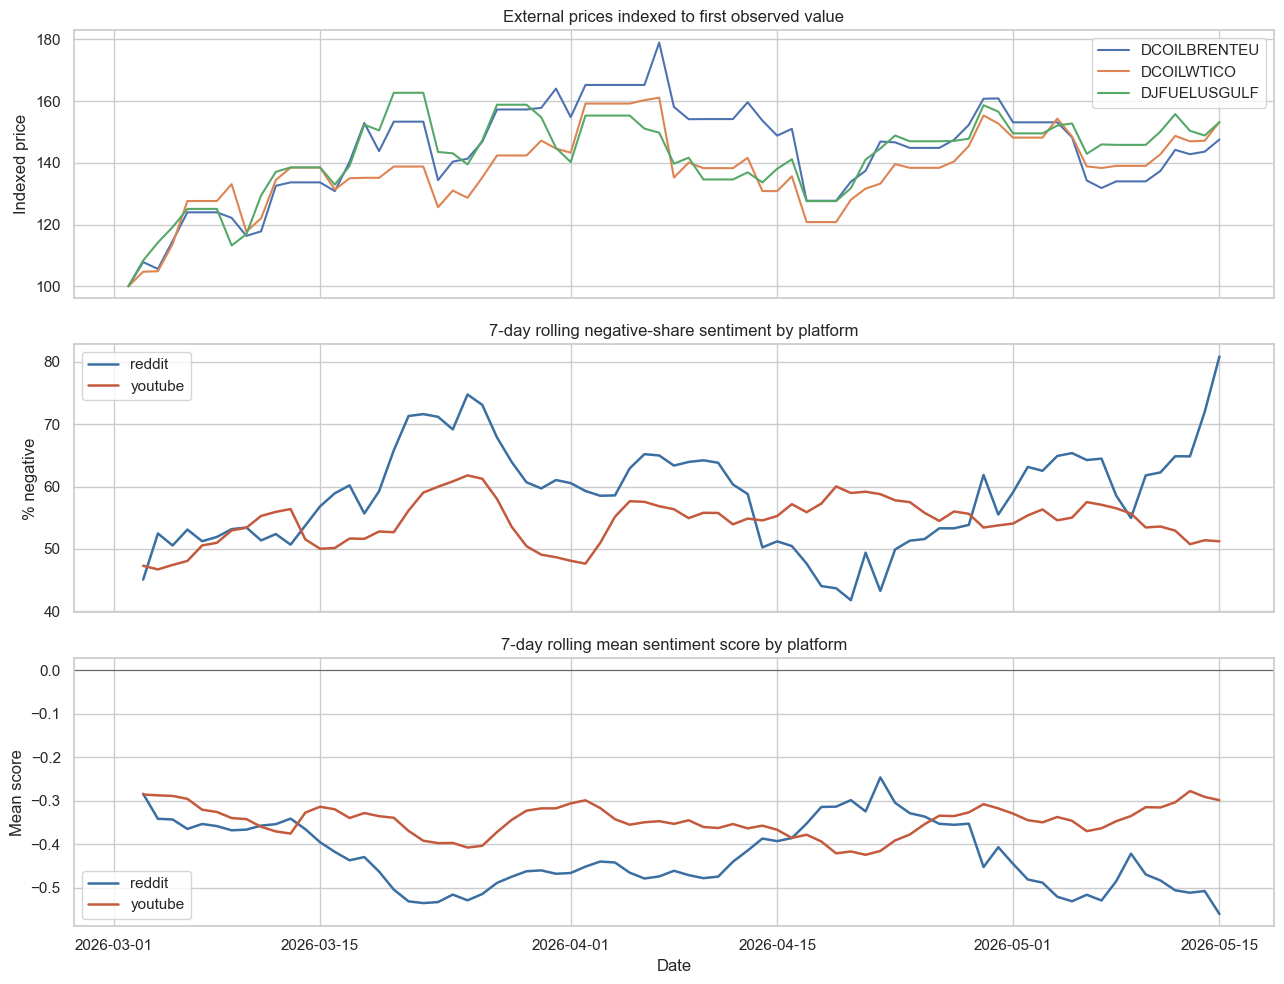

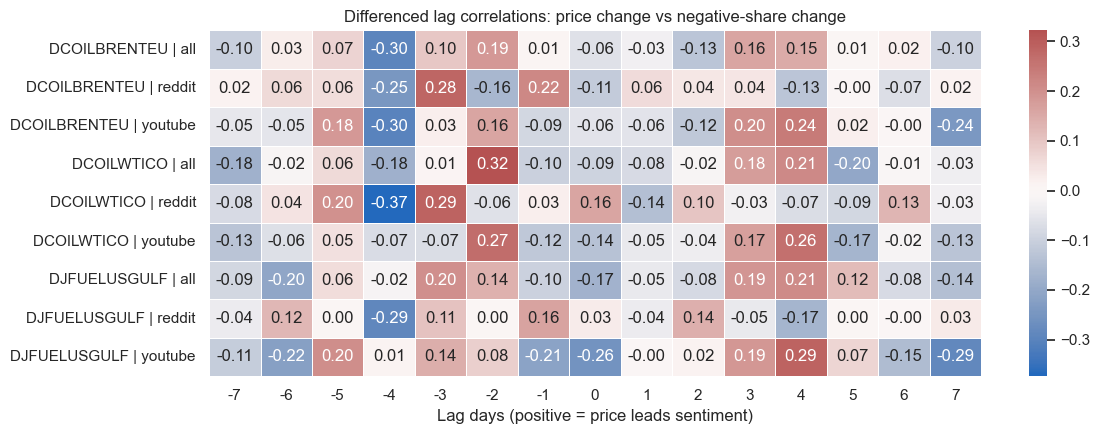

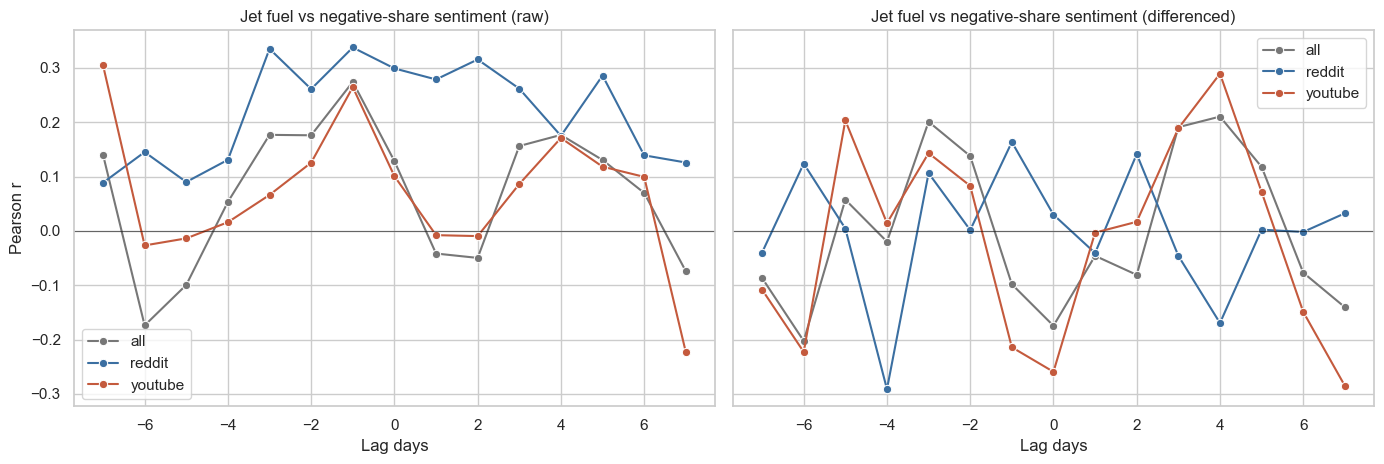

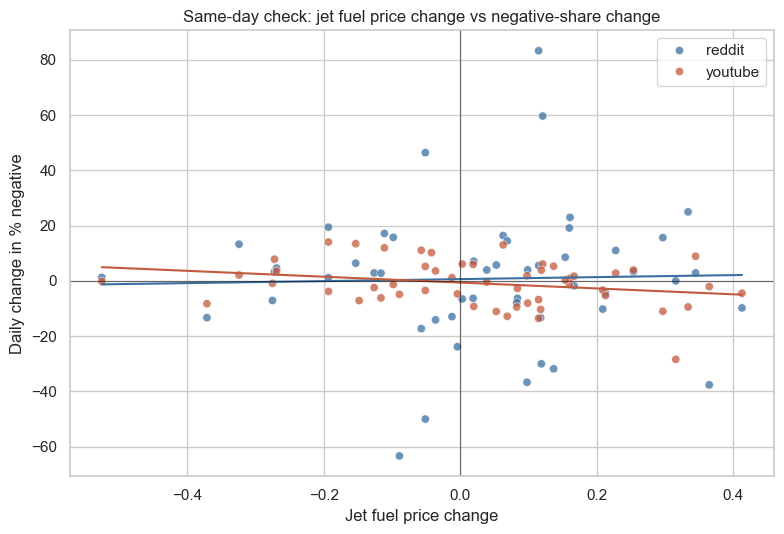

,series_id,series_label,platform,same_day_raw_r,same_day_raw_ci_lo,same_day_raw_ci_hi,same_day_diff_r,same_day_diff_ci_lo,same_day_diff_ci_hi,strongest_diff_lag_days,strongest_diff_r,strongest_diff_ci_lo,strongest_diff_ci_hi,strongest_stable_diff_lag_days,strongest_stable_diff_r,strongest_stable_diff_ci_lo,strongest_stable_diff_ci_hi,n_at_strongest_stable,temporal_interpretation
4,DCOILWTICO,WTI Cushing spot,reddit,0.284240,0.086790,0.473035,0.160434,-0.081208,0.353498,-4,-0.373506,-0.617477,-0.162967,-4.0,-0.373506,-0.617477,-0.162967,50.0,negative differenced association; negative-share change leads price change by 4 day(s); exploratory multiple-test result
3,DCOILWTICO,WTI Cushing spot,all,0.097444,-0.237464,0.385131,-0.093886,-0.382714,0.176646,-2,0.322249,0.096166,0.494800,-2.0,0.322249,0.096166,0.494800,52.0,positive differenced association; negative-share change leads price change by 2 day(s); exploratory multiple-test result
7,DJFUELUSGULF,US Gulf Coast jet fuel spot,reddit,0.299172,0.082185,0.494150,0.029868,-0.176864,0.210158,-4,-0.291316,-0.551356,-0.009461,-4.0,-0.291316,-0.551356,-0.009461,50.0,negative differenced association; negative-share change leads price change by 4 day(s); exploratory multiple-test result
5,DCOILWTICO,WTI Cushing spot,youtube,0.099022,-0.224124,0.377658,-0.135924,-0.349850,0.083565,-2,0.268738,0.035256,0.470041,-2.0,0.268738,0.035256,0.470041,52.0,positive differenced association; negative-share change leads price change by 2 day(s); exploratory multiple-test result
8,DJFUELUSGULF,US Gulf Coast jet fuel spot,youtube,0.100879,-0.247104,0.439566,-0.259337,-0.469176,-0.029422,4,0.289466,-0.009592,0.555069,0.0,-0.259337,-0.469176,-0.029422,53.0,negative differenced association; same-day association; exploratory multiple-test result
1,DCOILBRENTEU,Brent crude spot,reddit,0.078388,-0.125193,0.296345,-0.111777,-0.318830,0.100387,-3,0.283116,-0.057848,0.594997,-4.0,-0.245887,-0.474679,-0.047440,48.0,negative differenced association; negative-share change leads price change by 4 day(s); exploratory multiple-test result
0,DCOILBRENTEU,Brent crude spot,all,0.257155,-0.007822,0.498667,-0.063644,-0.373911,0.240333,-4,-0.296542,-0.525942,0.006077,NaN,NaN,NaN,NaN,NaN,no differenced negative-share lag has a bootstrap CI excluding zero
2,DCOILBRENTEU,Brent crude spot,youtube,0.246099,-0.054836,0.542626,-0.057024,-0.279527,0.188153,-4,-0.300556,-0.562917,0.020987,NaN,NaN,NaN,NaN,NaN,no differenced negative-share lag has a bootstrap CI excluding zero
6,DJFUELUSGULF,US Gulf Coast jet fuel spot,all,0.128609,-0.194127,0.422950,-0.174598,-0.457175,0.133748,4,0.210506,-0.050338,0.473115,NaN,NaN,NaN,NaN,NaN,no differenced negative-share lag has a bootstrap CI excluding zero


In [17]:
platform_order = ["all", "reddit", "youtube"]
plot_platforms = ["reddit", "youtube"]
platform_palette = {"all": NEUTRAL_COLOR, "reddit": REDDIT_COLOR, "youtube": YOUTUBE_COLOR}

sentiment_dates = pd.date_range(
    min(daily_outcomes["date"].min(), prices_long["date"].min()),
    max(daily_outcomes["date"].max(), prices_long["date"].max()),
    freq="D",
)

sentiment_frames = []
for platform in platform_order:
    d = (
        daily_outcomes[daily_outcomes["platform"] == platform]
        .set_index("date")
        .reindex(sentiment_dates)
        .rename_axis("date")
        .reset_index()
    )
    d["platform"] = platform
    d["comments"] = d["comments"].fillna(0)
    d = d.sort_values("date")
    d["comments_delta"] = d["comments"].diff()
    d["mean_sentiment_delta"] = d["mean_sentiment"].diff()
    d["pct_negative_delta"] = d["pct_negative"].diff()
    d["comments_7d_mean"] = d["comments"].rolling(7, min_periods=3).mean()
    d["mean_sentiment_7d"] = d["mean_sentiment"].rolling(7, min_periods=3).mean()
    d["pct_negative_7d"] = d["pct_negative"].rolling(7, min_periods=3).mean()
    sentiment_frames.append(d)

sentiment_daily_full = pd.concat(sentiment_frames, ignore_index=True)

price_frames = []
for series_id in sorted(prices_long["series_id"].dropna().unique()):
    p = prepare_price_series(prices_long, series_id)
    p = (
        p.set_index("date")
        .reindex(sentiment_dates)
        .rename_axis("date")
        .reset_index()
        .sort_values("date")
    )
    p[["series_id", "series_label"]] = p[["series_id", "series_label"]].ffill().bfill()
    first_price = p["price"].dropna().iloc[0] if p["price"].notna().any() else np.nan
    p["indexed_price"] = p["price"] / first_price * 100 if pd.notna(first_price) else np.nan
    p["indexed_price_ffill"] = p["indexed_price"].ffill()
    price_frames.append(p)

prices_daily_full = pd.concat(price_frames, ignore_index=True)
sentiment_external_daily = sentiment_daily_full.merge(prices_daily_full, on="date", how="left")
sentiment_external_daily.to_csv(COMPARISON / "sentiment_external_daily_aligned.csv", index=False)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for series_id, g in prices_daily_full.groupby("series_id"):
    axes[0].plot(g["date"], g["indexed_price_ffill"], linewidth=1.5, label=series_id)
axes[0].set_title("External prices indexed to first observed value")
axes[0].set_ylabel("Indexed price")
axes[0].legend(title="")

for platform in plot_platforms:
    g = sentiment_daily_full[sentiment_daily_full["platform"] == platform]
    axes[1].plot(
        g["date"],
        g["pct_negative_7d"],
        linewidth=1.8,
        color=platform_palette[platform],
        label=platform,
    )
axes[1].set_title("7-day rolling negative-share sentiment by platform")
axes[1].set_ylabel("% negative")
axes[1].legend(title="")

for platform in plot_platforms:
    g = sentiment_daily_full[sentiment_daily_full["platform"] == platform]
    axes[2].plot(
        g["date"],
        g["mean_sentiment_7d"],
        linewidth=1.8,
        color=platform_palette[platform],
        label=platform,
    )
axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[2].set_title("7-day rolling mean sentiment score by platform")
axes[2].set_ylabel("Mean score")
axes[2].set_xlabel("Date")
axes[2].legend(title="")
plt.tight_layout()
out = PLOTS / "sentiment_over_time_external_prices.png"
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()

sentiment_lag_checks = external_lags[external_lags["outcome"] == "negative_share"].copy()
sentiment_lag_checks.to_csv(COMPARISON / "sentiment_external_lag_correlations.csv", index=False)

sentiment_heat = sentiment_lag_checks[sentiment_lag_checks["transform"] == "differenced"].copy()
sentiment_heat["panel"] = sentiment_heat["series_id"] + " | " + sentiment_heat["platform"]
sentiment_pivot = sentiment_heat.pivot_table(index="panel", columns="lag_days", values="pearson_r", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, max(4.5, 0.45 * len(sentiment_pivot))))
sns.heatmap(sentiment_pivot, center=0, cmap="vlag", annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_title("Differenced lag correlations: price change vs negative-share change")
ax.set_xlabel("Lag days (positive = price leads sentiment)")
ax.set_ylabel("")
plt.tight_layout()
out = PLOTS / "external_sentiment_lag_correlation_heatmap.png"
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()

jet_sentiment = sentiment_lag_checks[
    (sentiment_lag_checks["series_id"] == "DJFUELUSGULF")
    & (sentiment_lag_checks["platform"].isin(platform_order))
]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, transform in zip(axes, ["raw", "differenced"]):
    data = jet_sentiment[jet_sentiment["transform"] == transform]
    sns.lineplot(
        data=data,
        x="lag_days",
        y="pearson_r",
        hue="platform",
        marker="o",
        palette=platform_palette,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title(f"Jet fuel vs negative-share sentiment ({transform})")
    ax.set_xlabel("Lag days")
    ax.set_ylabel("Pearson r")
    ax.legend(title="")
plt.tight_layout()
out = PLOTS / "external_jetfuel_sentiment_lag_lines.png"
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()

scatter = sentiment_external_daily[
    (sentiment_external_daily["series_id"] == "DJFUELUSGULF")
    & (sentiment_external_daily["platform"].isin(plot_platforms))
].dropna(subset=["price_delta", "pct_negative_delta"])
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(
    data=scatter,
    x="price_delta",
    y="pct_negative_delta",
    hue="platform",
    palette=platform_palette,
    alpha=0.75,
    ax=ax,
)
for platform in plot_platforms:
    g = scatter[scatter["platform"] == platform]
    if len(g) >= 3 and g["price_delta"].std() > 0 and g["pct_negative_delta"].std() > 0:
        x = g["price_delta"].to_numpy(dtype=float)
        y = g["pct_negative_delta"].to_numpy(dtype=float)
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, intercept + slope * xs, color=platform_palette[platform], linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Same-day check: jet fuel price change vs negative-share change")
ax.set_xlabel("Jet fuel price change")
ax.set_ylabel("Daily change in % negative")
ax.legend(title="")
plt.tight_layout()
out = PLOTS / "sentiment_price_change_scatter.png"
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()

temporal_rows = []
for keys, g in sentiment_lag_checks.dropna(subset=["pearson_r"]).groupby(["series_id", "series_label", "platform"]):
    raw = g[g["transform"] == "raw"]
    diff = g[g["transform"] == "differenced"]
    same_raw = raw[raw["lag_days"] == 0]
    same_diff = diff[diff["lag_days"] == 0]
    strongest_diff = diff.loc[diff["pearson_r"].abs().idxmax()] if not diff.empty else None
    stable_diff = diff[diff["ci_lo"] * diff["ci_hi"] > 0]
    strongest_stable = stable_diff.loc[stable_diff["pearson_r"].abs().idxmax()] if not stable_diff.empty else None

    if strongest_stable is not None:
        lag = int(strongest_stable["lag_days"])
        if lag > 0:
            lag_phrase = f"price leads negative-share change by {lag} day(s)"
        elif lag < 0:
            lag_phrase = f"negative-share change leads price change by {abs(lag)} day(s)"
        else:
            lag_phrase = "same-day association"
        direction = "positive" if strongest_stable["pearson_r"] > 0 else "negative"
        interpretation = f"{direction} differenced association; {lag_phrase}; exploratory multiple-test result"
    else:
        interpretation = "no differenced negative-share lag has a bootstrap CI excluding zero"

    temporal_rows.append({
        "series_id": keys[0],
        "series_label": keys[1],
        "platform": keys[2],
        "same_day_raw_r": float(same_raw["pearson_r"].iloc[0]) if not same_raw.empty else np.nan,
        "same_day_raw_ci_lo": float(same_raw["ci_lo"].iloc[0]) if not same_raw.empty else np.nan,
        "same_day_raw_ci_hi": float(same_raw["ci_hi"].iloc[0]) if not same_raw.empty else np.nan,
        "same_day_diff_r": float(same_diff["pearson_r"].iloc[0]) if not same_diff.empty else np.nan,
        "same_day_diff_ci_lo": float(same_diff["ci_lo"].iloc[0]) if not same_diff.empty else np.nan,
        "same_day_diff_ci_hi": float(same_diff["ci_hi"].iloc[0]) if not same_diff.empty else np.nan,
        "strongest_diff_lag_days": int(strongest_diff["lag_days"]) if strongest_diff is not None else np.nan,
        "strongest_diff_r": float(strongest_diff["pearson_r"]) if strongest_diff is not None else np.nan,
        "strongest_diff_ci_lo": float(strongest_diff["ci_lo"]) if strongest_diff is not None else np.nan,
        "strongest_diff_ci_hi": float(strongest_diff["ci_hi"]) if strongest_diff is not None else np.nan,
        "strongest_stable_diff_lag_days": int(strongest_stable["lag_days"]) if strongest_stable is not None else np.nan,
        "strongest_stable_diff_r": float(strongest_stable["pearson_r"]) if strongest_stable is not None else np.nan,
        "strongest_stable_diff_ci_lo": float(strongest_stable["ci_lo"]) if strongest_stable is not None else np.nan,
        "strongest_stable_diff_ci_hi": float(strongest_stable["ci_hi"]) if strongest_stable is not None else np.nan,
        "n_at_strongest_stable": int(strongest_stable["n"]) if strongest_stable is not None else np.nan,
        "temporal_interpretation": interpretation,
    })

sentiment_external_temporal_summary = pd.DataFrame(temporal_rows)
sentiment_external_temporal_summary["abs_stable_diff_r"] = sentiment_external_temporal_summary["strongest_stable_diff_r"].abs()
sentiment_external_temporal_summary = sentiment_external_temporal_summary.sort_values(
    ["abs_stable_diff_r", "series_id", "platform"],
    ascending=[False, True, True],
    na_position="last",
).drop(columns=["abs_stable_diff_r"])
sentiment_external_temporal_summary.to_csv(COMPARISON / "sentiment_external_temporal_summary.csv", index=False)

sentiment_external_temporal_summary.head(12)


## Generated artifacts

Relevant existing outputs from this notebook are:

- `data/processed/06_comparison/platform_comparison.csv`
- `data/processed/06_comparison/sentiment_test_results.csv`
- `data/processed/06_comparison/platform_specific_topic_prevalence.csv`
- `data/processed/06_comparison/topic_platform_chi2.csv`
- `data/processed/06_comparison/combined_topic_prevalence_by_platform.csv`
- `data/processed/06_comparison/external_validation_summary.csv`
- `data/processed/06_comparison/sentiment_external_daily_aligned.csv`
- `data/processed/06_comparison/sentiment_external_temporal_summary.csv`
- `data/processed/06_comparison/platform_comparison_interpretation.csv`
- `data/processed/06_comparison/external_validation_caveats.csv`
- `plots/platform_comparison_dashboard.png`
- `plots/sentiment_platform_comparison_clean.png`
- `plots/sentiment_over_time_external_prices.png`

## Report-ready findings

- Reddit and YouTube share broad crisis frames, but the larger difference is structural: Reddit is more conversational; YouTube is broader and shallower.
- Cross-platform sentiment differences are statistically testable but should be interpreted with effect sizes, not p-values alone.
- External price analysis is temporal context only. The lag tables and final time-series figure help compare timing, but they are not causal validation or prediction.
